#  Classificação de Sementes de Cacau com CNN + SVM

## Trabalho Pedagógico Complementar - Machine Learning Aplicado 2

**Universidade do Estado do Amazonas - Escola Superior de Tecnologia**

**Docente:** Profª Elloá B. Guedes

---

###  Objetivo

Este trabalho implementa um pipeline de classificação de sementes de cacau no teste de corte, utilizando:
- **CNNs pré-treinadas** (VGG16, VGG19, ResNet50, InceptionV3, MobileNetV2) como extratoras de características
- **SVMs** como classificadores finais
- **Transfer Learning** para aproveitar conhecimento de grandes bases de dados (ImageNet)

###  Meta
Superar o baseline de **89,79%** reportado por Malcher and Guedes (2022).

###  Referências Base
- Santos et al. (2019) - Dataset de sementes de cacau
- Malcher and Guedes (2022) - Baseline de 89.79% com CNNs
- Sarkar et al. (2018) - Transfer Learning com Python

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
##  1. Configuração do Ambiente

Instalação das dependências e importação das bibliotecas necessárias.

In [2]:
# Instalação de Dependências
!pip install -q tensorflow scikit-learn matplotlib seaborn pandas numpy pillow

print("Dependências instaladas com sucesso!")

Dependências instaladas com sucesso!


In [3]:
# Importação de Bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from tensorflow.keras.applications import (
    VGG16, VGG19, ResNet50, InceptionV3, MobileNetV2
)
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.inception_v3 import preprocess_input as inception_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.models import Model
from PIL import Image
import os
import time
import warnings
warnings.filterwarnings('ignore')

# Configuração de visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [4]:
# Montar o Google Drive
from google.colab import drive
drive.mount("/content/drive")
print("Drive montado!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive montado!


In [5]:
# ============================================================
# IMPORTANTE: Ajuste o caminho do dataset conforme necessário
# ============================================================
DATASET_DIR = "/content/drive/MyDrive/Dataset Cocoa Beans/Enquadrado e Centralizado - Versão 1 - Método A"

if not os.path.exists(DATASET_DIR):
    raise FileNotFoundError(f"Caminho não encontrado: {DATASET_DIR}")

print(f"Dataset encontrado: {DATASET_DIR}")

Dataset encontrado: /content/drive/MyDrive/Dataset Cocoa Beans/Enquadrado e Centralizado - Versão 1 - Método A


---
## 2. Análise Exploratória de Dados (EDA)

Nesta seção, realizamos a análise exploratória do dataset de sementes de cacau, incluindo:

1. **Identificação das classes** presentes no dataset
2. **Distribuição de imagens** por classe (verificação de balanceamento)
3. **Inspeção de qualidade** das imagens (formato, dimensões, canais)
4. **Visualização de amostras** de cada classe

O dataset foi proposto por Santos et al. (2019) e contém imagens do teste de corte do cacau.

In [6]:
# Identificar classes do dataset
classes = sorted([d for d in os.listdir(DATASET_DIR)
                  if os.path.isdir(os.path.join(DATASET_DIR, d))])

print(f"{'='*60}")
print(f"CLASSES ENCONTRADAS NO DATASET")
print(f"{'='*60}")
for i, cls in enumerate(classes, 1):
    print(f"{i:2d}. {cls}")
print(f"{'='*60}")
print(f"Total de classes: {len(classes)}")

CLASSES ENCONTRADAS NO DATASET
 1. Agglutinated
 2. Brittle
 3. Compartmentalized_Brown
 4. Compartmentalized_PartiallyPurple
 5. Compartmentalized_Purple
 6. Compartmentalized_Slaty
 7. Compartmentalized_White
 8. Flattened
 9. Moldered
10. Plated_Brown
11. Plated_PartiallyPurple
12. Plated_Purple
13. Plated_Slaty
14. Plated_White
Total de classes: 14


In [7]:
# Contagem de imagens por classe
print("\nAnalisando distribuição de imagens...\n")

class_counts = {}
all_images = []

for cls in classes:
    class_path = os.path.join(DATASET_DIR, cls)
    images = [f for f in os.listdir(class_path)
              if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    class_counts[cls] = len(images)

    for img in images:
        all_images.append({
            'class': cls,
            'path': os.path.join(class_path, img),
            'filename': img
        })

df = pd.DataFrame(all_images)

# Exibir distribuição
print(f"{'='*60}")
print(f"DISTRIBUIÇÃO DE IMAGENS POR CLASSE")
print(f"{'='*60}")
for cls, count in sorted(class_counts.items()):
    pct = count/len(df)*100
    bar = '█' * int(pct/2)
    print(f"{cls:35s}: {count:4d} ({pct:5.2f}%) {bar}")
print(f"{'='*60}")
print(f"TOTAL DE IMAGENS: {len(df)}")
print(f"{'='*60}")


Analisando distribuição de imagens...

DISTRIBUIÇÃO DE IMAGENS POR CLASSE
Agglutinated                       :  100 ( 7.14%) ███
Brittle                            :  100 ( 7.14%) ███
Compartmentalized_Brown            :  100 ( 7.14%) ███
Compartmentalized_PartiallyPurple  :  100 ( 7.14%) ███
Compartmentalized_Purple           :  100 ( 7.14%) ███
Compartmentalized_Slaty            :  100 ( 7.14%) ███
Compartmentalized_White            :  100 ( 7.14%) ███
Flattened                          :  100 ( 7.14%) ███
Moldered                           :  100 ( 7.14%) ███
Plated_Brown                       :  100 ( 7.14%) ███
Plated_PartiallyPurple             :  100 ( 7.14%) ███
Plated_Purple                      :  100 ( 7.14%) ███
Plated_Slaty                       :  100 ( 7.14%) ███
Plated_White                       :  100 ( 7.14%) ███
TOTAL DE IMAGENS: 1400


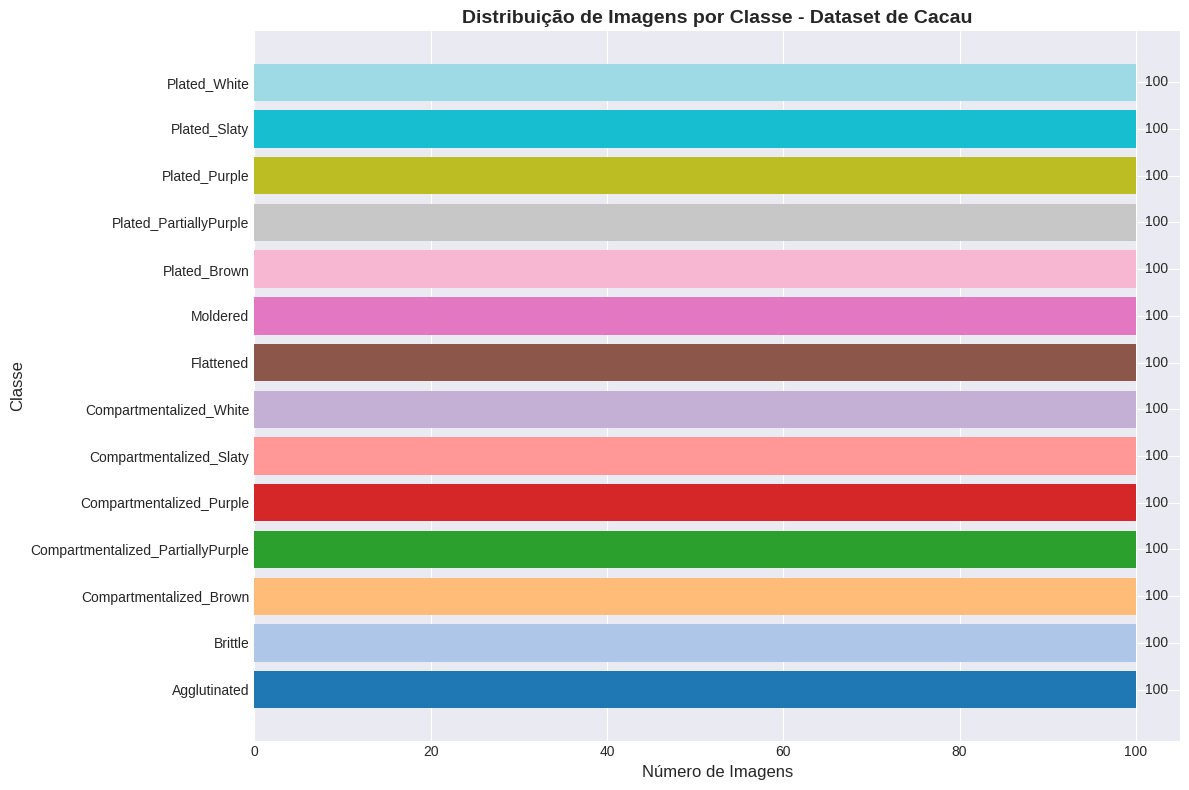


Gráfico salvo: distribuicao_classes.png


In [8]:
# Gráfico de distribuição de classes
fig, ax = plt.subplots(figsize=(12, 8))

colors = plt.cm.tab20(np.linspace(0, 1, len(classes)))
bars = ax.barh(list(class_counts.keys()), list(class_counts.values()), color=colors)

ax.set_xlabel('Número de Imagens', fontsize=12)
ax.set_ylabel('Classe', fontsize=12)
ax.set_title('Distribuição de Imagens por Classe - Dataset de Cacau', fontsize=14, fontweight='bold')

# Adicionar valores nas barras
for bar, count in zip(bars, class_counts.values()):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{count}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('distribuicao_classes.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nGráfico salvo: distribuicao_classes.png")

In [9]:
# Inspeção de qualidade e formato das imagens
print("\nINSPEÇÃO DE QUALIDADE DAS IMAGENS")
print("="*60)

# Analisar amostras de cada classe
quality_info = []

for cls in classes:
    class_path = os.path.join(DATASET_DIR, cls)
    images = [f for f in os.listdir(class_path)
              if f.lower().endswith(('.png', '.jpg', '.jpeg'))][:5]  # Amostra de 5

    for img_name in images:
        img_path = os.path.join(class_path, img_name)
        with Image.open(img_path) as img:
            quality_info.append({
                'class': cls,
                'filename': img_name,
                'width': img.size[0],
                'height': img.size[1],
                'mode': img.mode,
                'format': img.format
            })

quality_df = pd.DataFrame(quality_info)

print(f"\nDIMENSÕES DAS IMAGENS:")
print(f"   Largura  - Min: {quality_df['width'].min()}, Max: {quality_df['width'].max()}, Média: {quality_df['width'].mean():.0f}")
print(f"   Altura   - Min: {quality_df['height'].min()}, Max: {quality_df['height'].max()}, Média: {quality_df['height'].mean():.0f}")

print(f"\nMODO DE COR:")
for mode, count in quality_df['mode'].value_counts().items():
    print(f"   {mode}: {count} imagens")

print(f"\nFORMATO:")
for fmt, count in quality_df['format'].value_counts().items():
    print(f"   {fmt}: {count} imagens")

print("\n" + "="*60)
print("Conclusão: Dataset com imagens de boa qualidade, formato consistente")


INSPEÇÃO DE QUALIDADE DAS IMAGENS

DIMENSÕES DAS IMAGENS:
   Largura  - Min: 899, Max: 1971, Média: 1211
   Altura   - Min: 883, Max: 2627, Média: 2076

MODO DE COR:
   RGB: 70 imagens

FORMATO:
   JPEG: 70 imagens

Conclusão: Dataset com imagens de boa qualidade, formato consistente



VISUALIZAÇÃO DE AMOSTRAS POR CLASSE



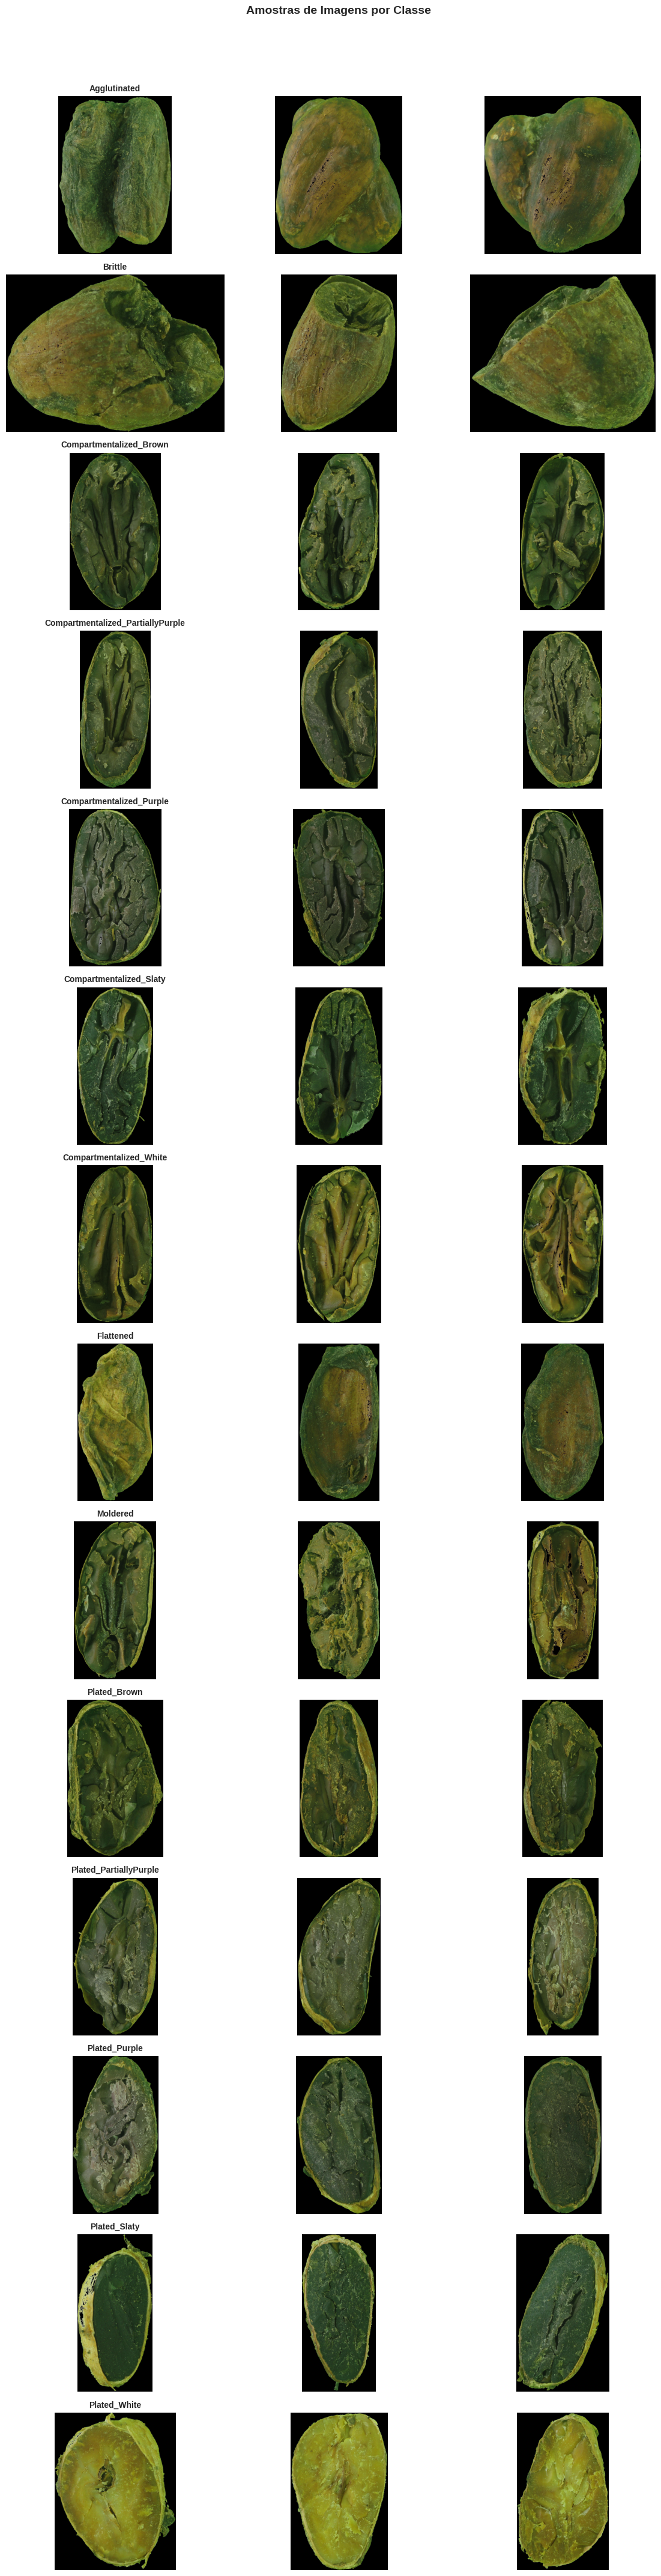


Gráfico salvo: amostras_classes.png


In [10]:
# Visualização de amostras de cada classe
print("\nVISUALIZAÇÃO DE AMOSTRAS POR CLASSE\n")

n_samples = 3  # Amostras por classe
n_classes = len(classes)

fig, axes = plt.subplots(n_classes, n_samples, figsize=(12, 3*n_classes))

for i, cls in enumerate(classes):
    class_path = os.path.join(DATASET_DIR, cls)
    images = [f for f in os.listdir(class_path)
              if f.lower().endswith(('.png', '.jpg', '.jpeg'))][:n_samples]

    for j, img_name in enumerate(images):
        img_path = os.path.join(class_path, img_name)
        img = Image.open(img_path)

        ax = axes[i, j] if n_classes > 1 else axes[j]
        ax.imshow(img)
        ax.axis('off')
        if j == 0:
            ax.set_title(cls, fontsize=10, fontweight='bold')

plt.suptitle('Amostras de Imagens por Classe', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('amostras_classes.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nGráfico salvo: amostras_classes.png")

---
##  3. Preparação dos Dados

Nesta seção, realizamos:

1. **Codificação dos rótulos** (LabelEncoder)
2. **Divisão treino/teste** com estratificação (holdout 70/30)
3. **Padronização** dos caminhos das imagens

A partição será utilizada de forma consistente em todos os experimentos.

In [11]:
# Preparação dos dados
print("\nPREPARAÇÃO DOS DADOS")
print("="*60)

# Codificar labels
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['class'])

print("\nMapeamento de Classes:")
for i, cls in enumerate(label_encoder.classes_):
    print(f"   {i:2d} → {cls}")

# Divisão treino/teste estratificada
X = df['path'].values
y = df['label'].values

X_train_paths, X_test_paths, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print(f"\nDIVISÃO DOS DADOS:")
print(f"   Treino: {len(X_train_paths)} imagens ({len(X_train_paths)/len(df)*100:.1f}%)")
print(f"   Teste:  {len(X_test_paths)} imagens ({len(X_test_paths)/len(df)*100:.1f}%)")

# Verificar estratificação
print(f"\nEstratificação verificada:")
train_dist = pd.Series(y_train).value_counts().sort_index()
test_dist = pd.Series(y_test).value_counts().sort_index()
print(f"   Treino - Classes balanceadas: {train_dist.min()} a {train_dist.max()} por classe")
print(f"   Teste  - Classes balanceadas: {test_dist.min()} a {test_dist.max()} por classe")


PREPARAÇÃO DOS DADOS

Mapeamento de Classes:
    0 → Agglutinated
    1 → Brittle
    2 → Compartmentalized_Brown
    3 → Compartmentalized_PartiallyPurple
    4 → Compartmentalized_Purple
    5 → Compartmentalized_Slaty
    6 → Compartmentalized_White
    7 → Flattened
    8 → Moldered
    9 → Plated_Brown
   10 → Plated_PartiallyPurple
   11 → Plated_Purple
   12 → Plated_Slaty
   13 → Plated_White

DIVISÃO DOS DADOS:
   Treino: 980 imagens (70.0%)
   Teste:  420 imagens (30.0%)

Estratificação verificada:
   Treino - Classes balanceadas: 70 a 70 por classe
   Teste  - Classes balanceadas: 30 a 30 por classe


---
##  4. Extração de Características com CNNs

Utilizamos 5 arquiteturas de CNNs pré-treinadas no ImageNet como extratoras de características:

| CNN | Camadas | Dimensão Features | Input Size |
|-----|---------|-------------------|------------|
| VGG16 | 16 | 512 | 224×224 |
| VGG19 | 19 | 512 | 224×224 |
| ResNet50 | 50 | 2048 | 224×224 |
| InceptionV3 | 48 | 2048 | 299×299 |
| MobileNetV2 | 53 | 1280 | 224×224 |

As CNNs são utilizadas **sem as camadas finais de classificação**, com pesos fixos (congelados), apenas para extrair vetores de características visuais.

In [12]:
# Definição das arquiteturas CNN
cnn_models = {
    'VGG16': {
        'model_fn': VGG16,
        'preprocess': vgg_preprocess,
        'input_size': (224, 224),
        'feature_dim': 512
    },
    'VGG19': {
        'model_fn': VGG19,
        'preprocess': vgg_preprocess,
        'input_size': (224, 224),
        'feature_dim': 512
    },
    'ResNet50': {
        'model_fn': ResNet50,
        'preprocess': resnet_preprocess,
        'input_size': (224, 224),
        'feature_dim': 2048
    },
    'InceptionV3': {
        'model_fn': InceptionV3,
        'preprocess': inception_preprocess,
        'input_size': (299, 299),
        'feature_dim': 2048
    },
    'MobileNetV2': {
        'model_fn': MobileNetV2,
        'preprocess': mobilenet_preprocess,
        'input_size': (224, 224),
        'feature_dim': 1280
    }
}

print("\nARQUITETURAS CNN CONFIGURADAS:")
print("="*60)
print(f"{'CNN':<15} {'Input Size':<12} {'Features':<10}")
print("-"*60)
for name, config in cnn_models.items():
    print(f"{name:<15} {str(config['input_size']):<12} {config['feature_dim']:<10}")
print("="*60)


ARQUITETURAS CNN CONFIGURADAS:
CNN             Input Size   Features  
------------------------------------------------------------
VGG16           (224, 224)   512       
VGG19           (224, 224)   512       
ResNet50        (224, 224)   2048      
InceptionV3     (299, 299)   2048      
MobileNetV2     (224, 224)   1280      


In [13]:
# Função para extrair características
def extract_features(image_paths, cnn_name, verbose=True):
    """
    Extrai características visuais usando uma CNN pré-treinada.

    Args:
        image_paths: Lista de caminhos das imagens
        cnn_name: Nome da CNN ('VGG16', 'VGG19', etc.)
        verbose: Se True, mostra progresso

    Returns:
        numpy array com features extraídas
    """
    config = cnn_models[cnn_name]
    input_size = config['input_size']
    preprocess = config['preprocess']

    # Carregar modelo base
    base_model = config['model_fn'](weights='imagenet', include_top=False, pooling='avg')

    if verbose:
        print(f"\nExtraindo características com {cnn_name}...")
        print(f"   Input size: {input_size}")
        print(f"   Feature dimension: {config['feature_dim']}")

    features = []
    n_images = len(image_paths)

    for i, img_path in enumerate(image_paths):
        # Carregar e preprocessar imagem
        img = image.load_img(img_path, target_size=input_size)
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array = preprocess(img_array)

        # Extrair features
        feat = base_model.predict(img_array, verbose=0)
        features.append(feat.flatten())

        # Progresso
        if verbose and (i + 1) % 100 == 0:
            print(f"Processadas {i+1}/{n_images} imagens ({(i+1)/n_images*100:.1f}%)")

    if verbose:
        print(f"Extração concluída! Shape: ({len(features)}, {len(features[0])})")

    return np.array(features)

In [14]:
# Extrair características de todas as CNNs
features_dict = {}

print("\n" + "="*70)
print("INICIANDO EXTRAÇÃO DE CARACTERÍSTICAS")
print("="*70)
print("Tempo estimado: ~15-25 minutos para todas as CNNs\n")

total_start = time.time()

for cnn_idx, cnn_name in enumerate(cnn_models.keys(), 1):
    print(f"\n{'='*70}")
    print(f"[{cnn_idx}/{len(cnn_models)}] CNN: {cnn_name}")
    print(f"{'='*70}")

    start_time = time.time()

    # Extrair features do conjunto de treino
    print(f"\nConjunto de TREINO:")
    X_train_features = extract_features(X_train_paths, cnn_name, verbose=True)

    # Extrair features do conjunto de teste
    print(f"\nConjunto de TESTE:")
    X_test_features = extract_features(X_test_paths, cnn_name, verbose=True)

    # Armazenar
    features_dict[cnn_name] = {
        'X_train': X_train_features,
        'X_test': X_test_features
    }

    elapsed = time.time() - start_time
    print(f"\n{cnn_name} concluído em {elapsed/60:.1f} minutos")
    print(f"   Shape treino: {X_train_features.shape}")
    print(f"   Shape teste:  {X_test_features.shape}")

total_elapsed = time.time() - total_start
print(f"\n{'='*70}")
print(f"EXTRAÇÃO COMPLETA!")
print(f"Tempo total: {total_elapsed/60:.1f} minutos")
print(f"{'='*70}")


INICIANDO EXTRAÇÃO DE CARACTERÍSTICAS
Tempo estimado: ~15-25 minutos para todas as CNNs


[1/5] CNN: VGG16

Conjunto de TREINO:
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

Extraindo características com VGG16...
   Input size: (224, 224)
   Feature dimension: 512
Processadas 100/980 imagens (10.2%)
Processadas 200/980 imagens (20.4%)
Processadas 300/980 imagens (30.6%)
Processadas 400/980 imagens (40.8%)
Processadas 500/980 imagens (51.0%)
Processadas 600/980 imagens (61.2%)
Processadas 700/980 imagens (71.4%)
Processadas 800/980 imagens (81.6%)
Processadas 900/980 imagens (91.8%)
Extração concluída! Shape: (980, 512)

Conjunto de TESTE:

Extraindo características com VGG16...
   Input size: (224, 224)
   Feature dimension: 512
Processadas 100/420 imagens (23.8%)
Processadas 200/420 imagens (47.6%)
Processadas 300/420 imagens (71.4%)
Processadas 400/420 imagens (95.2%)
Extração concluída! Shape: (420, 512)

VGG16 concluído em 2.7 minutos
   Shape treino: (980, 512)
   Shape tes

---
##  5. Elaboração da Busca em Grade (Grid Search)

### 5.1 Definição dos Hiperparâmetros

A grade de busca para SVMs contempla os seguintes hiperparâmetros:

#### C (Regularização)
- **0.1**: Alta regularização, margem mais larga, mais tolerante a erros
- **1**: Valor padrão, equilíbrio entre margem e classificação correta
- **10, 100**: Baixa regularização, ajuste mais estrito aos dados de treino

#### Kernel
- **'rbf'**: Kernel Gaussiano (Radial Basis Function), projeta dados para espaço de maior dimensão
- **'linear'**: Kernel linear, eficiente quando dados são linearmente separáveis
- **'poly'**: Kernel polinomial, captura relações não-lineares

#### Gamma (para kernels não-lineares)
- **'scale'**: Valor adaptativo = 1/(n_features × X.var()), ajusta automaticamente
- **'auto'**: Valor = 1/n_features
- **0.01, 0.001**: Valores fixos conservadores

In [15]:
# ============================================================
# GRADE DE HIPERPARÂMETROS EXPANDIDA
# ============================================================

param_grid = {
    'C': [0.1, 1, 10, 100],              # 4 valores de regularização
    'kernel': ['rbf', 'linear', 'poly'], # 3 kernels
    'gamma': ['scale', 'auto', 0.01, 0.001],  # 4 valores de gamma
    'degree': [2, 3]                     # para kernel poly
}

# Nota: degree só é usado quando kernel='poly'
# Total teórico: 4 × 3 × 4 × 2 = 96, mas na prática menos devido às combinações válidas

print("\n" + "="*70)
print("GRADE DE HIPERPARÂMETROS PARA SVM")
print("="*70)
print(f"\nC (Regularização):     {param_grid['C']}")
print(f"Kernel:                {param_grid['kernel']}")
print(f"Gamma:                 {param_grid['gamma']}")
print(f"Degree (poly):         {param_grid['degree']}")
print("="*70)

print("\nJUSTIFICATIVA DOS HIPERPARÂMETROS:")
print("\n1. C (Regularização):")
print("   • 0.1  → Alta regularização, margem larga, tolerante a outliers")
print("   • 1    → Padrão, equilíbrio entre margem e classificação correta")
print("   • 10   → Baixa regularização, ajuste mais estrito aos dados")
print("   • 100  → Muito baixa regularização, risco de overfitting")

print("\n2. Kernel:")
print("   • RBF    → Kernel gaussiano, mapeia para espaço não-linear")
print("   • Linear → Baseline, eficiente se dados são linearmente separáveis")
print("   • Poly   → Captura relações polinomiais entre features")

print("\n3. Gamma (para RBF e Poly):")
print("   • 'scale' → Automático: 1/(n_features × X.var())")
print("   • 'auto'  → Automático: 1/n_features")
print("   • 0.01    → Valor fixo moderado")
print("   • 0.001   → Valor fixo conservador, maior generalização")


GRADE DE HIPERPARÂMETROS PARA SVM

C (Regularização):     [0.1, 1, 10, 100]
Kernel:                ['rbf', 'linear', 'poly']
Gamma:                 ['scale', 'auto', 0.01, 0.001]
Degree (poly):         [2, 3]

JUSTIFICATIVA DOS HIPERPARÂMETROS:

1. C (Regularização):
   • 0.1  → Alta regularização, margem larga, tolerante a outliers
   • 1    → Padrão, equilíbrio entre margem e classificação correta
   • 10   → Baixa regularização, ajuste mais estrito aos dados
   • 100  → Muito baixa regularização, risco de overfitting

2. Kernel:
   • RBF    → Kernel gaussiano, mapeia para espaço não-linear
   • Linear → Baseline, eficiente se dados são linearmente separáveis
   • Poly   → Captura relações polinomiais entre features

3. Gamma (para RBF e Poly):
   • 'scale' → Automático: 1/(n_features × X.var())
   • 'auto'  → Automático: 1/n_features
   • 0.01    → Valor fixo moderado
   • 0.001   → Valor fixo conservador, maior generalização


---
##  6. Execução dos Experimentos

Para cada CNN:
1. Carregar features extraídas
2. **Aplicar normalização** (StandardScaler)
3. Executar Grid Search com 5-fold Cross-Validation
4. Avaliar no conjunto de teste
5. Coletar métricas: Acurácia, Precisão, Recall, F1-Score

In [16]:
# Execução dos experimentos com Grid Search
results = []

print("\n" + "="*70)
print("INICIANDO EXPERIMENTOS - GRID SEARCH + SVM")
print("="*70)
print(f"\nValidação Cruzada: 5-fold")
print(f"Métrica de otimização: Accuracy")
print(f"Tempo estimado: ~30-60 minutos\n")

for cnn_idx, cnn_name in enumerate(cnn_models.keys(), 1):
    print(f"\n{'='*70}")
    print(f"[{cnn_idx}/{len(cnn_models)}] GRID SEARCH: {cnn_name}")
    print(f"{'='*70}")

    # Carregar features
    X_train = features_dict[cnn_name]['X_train']
    X_test = features_dict[cnn_name]['X_test']

    print(f"\nShape features treino: {X_train.shape}")
    print(f"Shape features teste:  {X_test.shape}")

    # ============================================================
    # NORMALIZAÇÃO DOS DADOS (IMPORTANTE!)
    # ============================================================
    print(f"\nAplicando normalização (StandardScaler)...")
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    print(f"Dados normalizados")

    # Criar SVM e GridSearchCV
    svm = SVC(random_state=42)

    grid_search = GridSearchCV(
        estimator=svm,
        param_grid=param_grid,
        cv=5,                    # 5-fold cross-validation
        scoring='accuracy',
        n_jobs=-1,               # Usar todos os cores
        verbose=1,
        return_train_score=True
    )

    # Treinar
    print(f"\nIniciando treinamento...")
    start_time = time.time()
    grid_search.fit(X_train_scaled, y_train)
    training_time = time.time() - start_time

    # Melhor modelo
    best_model = grid_search.best_estimator_

    print(f"\nMELHORES HIPERPARÂMETROS:")
    for param, value in grid_search.best_params_.items():
        print(f"   {param}: {value}")
    print(f"\nTempo de treinamento: {training_time/60:.1f} min")
    print(f"Melhor CV Score: {grid_search.best_score_:.4f}")

    # Avaliar no teste
    print(f"\nAvaliando no conjunto de teste...")
    y_pred = best_model.predict(X_test_scaled)

    # Calcular métricas
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    # Armazenar resultado
    result = {
        'CNN': cnn_name,
        'Best_Params': grid_search.best_params_,
        'CV_Score': grid_search.best_score_,
        'Training_Time': training_time,
        'Test_Accuracy': accuracy,
        'Test_Precision': precision,
        'Test_Recall': recall,
        'Test_F1': f1,
        'Confusion_Matrix': confusion_matrix(y_test, y_pred),
        'y_pred': y_pred,
        'best_model': best_model,
        'scaler': scaler
    }
    results.append(result)

    print(f"\nRESULTADOS NO TESTE - {cnn_name}:")
    print(f"   Acurácia:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"   Precisão:  {precision:.4f}")
    print(f"   Revocação: {recall:.4f}")
    print(f"   F1-Score:  {f1:.4f}")

print(f"\n{'='*70}")
print("TODOS OS EXPERIMENTOS CONCLUÍDOS!")
print(f"{'='*70}")


INICIANDO EXPERIMENTOS - GRID SEARCH + SVM

Validação Cruzada: 5-fold
Métrica de otimização: Accuracy
Tempo estimado: ~30-60 minutos


[1/5] GRID SEARCH: VGG16

Shape features treino: (980, 512)
Shape features teste:  (420, 512)

Aplicando normalização (StandardScaler)...
Dados normalizados

Iniciando treinamento...
Fitting 5 folds for each of 96 candidates, totalling 480 fits

MELHORES HIPERPARÂMETROS:
   C: 10
   degree: 2
   gamma: 0.001
   kernel: rbf

Tempo de treinamento: 3.3 min
Melhor CV Score: 0.6571

Avaliando no conjunto de teste...

RESULTADOS NO TESTE - VGG16:
   Acurácia:  0.6714 (67.14%)
   Precisão:  0.6883
   Revocação: 0.6714
   F1-Score:  0.6738

[2/5] GRID SEARCH: VGG19

Shape features treino: (980, 512)
Shape features teste:  (420, 512)

Aplicando normalização (StandardScaler)...
Dados normalizados

Iniciando treinamento...
Fitting 5 folds for each of 96 candidates, totalling 480 fits

MELHORES HIPERPARÂMETROS:
   C: 10
   degree: 2
   gamma: 0.001
   kernel: rbf


---
##  7. Análise dos Resultados

Nesta seção, apresentamos:

1. **Tabela comparativa** de todos os modelos
2. **Matrizes de confusão** dos 3 melhores modelos
3. **Comparação com o baseline** de 89,79% (Malcher and Guedes, 2022)
4. **Análise de erros** por classe

In [17]:
# Tabela comparativa de resultados

results_df = pd.DataFrame([
    {
        'CNN': r['CNN'],
        'Features': cnn_models[r['CNN']]['feature_dim'],
        'C': r['Best_Params']['C'],
        'Kernel': r['Best_Params']['kernel'],
        'Gamma': r['Best_Params'].get('gamma', 'N/A'),
        'CV_Score': r['CV_Score'],
        'Training_Time_min': r['Training_Time']/60,
        'Accuracy': r['Test_Accuracy'],
        'Precision': r['Test_Precision'],
        'Recall': r['Test_Recall'],
        'F1_Score': r['Test_F1']
    }
    for r in results
])

# Ordenar por acurácia
results_df = results_df.sort_values('Accuracy', ascending=False)

print("\n" + "="*110)
print("TABELA COMPARATIVA DE RESULTADOS")
print("="*110)

# Formatar para exibição
display_df = results_df.copy()
display_df['CV_Score'] = display_df['CV_Score'].apply(lambda x: f"{x:.4f}")
display_df['Training_Time_min'] = display_df['Training_Time_min'].apply(lambda x: f"{x:.2f}")
display_df['Accuracy'] = display_df['Accuracy'].apply(lambda x: f"{x:.4f}")
display_df['Precision'] = display_df['Precision'].apply(lambda x: f"{x:.4f}")
display_df['Recall'] = display_df['Recall'].apply(lambda x: f"{x:.4f}")
display_df['F1_Score'] = display_df['F1_Score'].apply(lambda x: f"{x:.4f}")

print(display_df.to_string(index=False))
print("="*110)


TABELA COMPARATIVA DE RESULTADOS
        CNN  Features    C Kernel  Gamma CV_Score Training_Time_min Accuracy Precision Recall F1_Score
   ResNet50      2048  0.1 linear  scale   0.7204             12.42   0.7357    0.7498 0.7357   0.7369
      VGG16       512 10.0    rbf  0.001   0.6571              3.27   0.6714    0.6883 0.6714   0.6738
MobileNetV2      1280  0.1 linear  scale   0.6837              7.53   0.6690    0.6836 0.6690   0.6719
InceptionV3      2048  0.1 linear  scale   0.6449             12.39   0.6643    0.6762 0.6643   0.6665
      VGG19       512 10.0    rbf  0.001   0.6541              2.75   0.6357    0.6454 0.6357   0.6355


In [18]:
# Identificar os 3 melhores modelos
sorted_results = sorted(results, key=lambda x: x['Test_Accuracy'], reverse=True)
top_3 = sorted_results[:3]

print("\n" + "="*70)
print("TOP 3 MELHORES MODELOS")
print("="*70)

for i, r in enumerate(top_3, 1):
    print(f"\n{i}º Lugar: {r['CNN']}")
    print(f"   Acurácia: {r['Test_Accuracy']*100:.2f}%")
    print(f"   Params: C={r['Best_Params']['C']}, kernel={r['Best_Params']['kernel']}, gamma={r['Best_Params'].get('gamma', 'N/A')}")


TOP 3 MELHORES MODELOS

1º Lugar: ResNet50
   Acurácia: 73.57%
   Params: C=0.1, kernel=linear, gamma=scale

2º Lugar: VGG16
   Acurácia: 67.14%
   Params: C=10, kernel=rbf, gamma=0.001

3º Lugar: MobileNetV2
   Acurácia: 66.90%
   Params: C=0.1, kernel=linear, gamma=scale


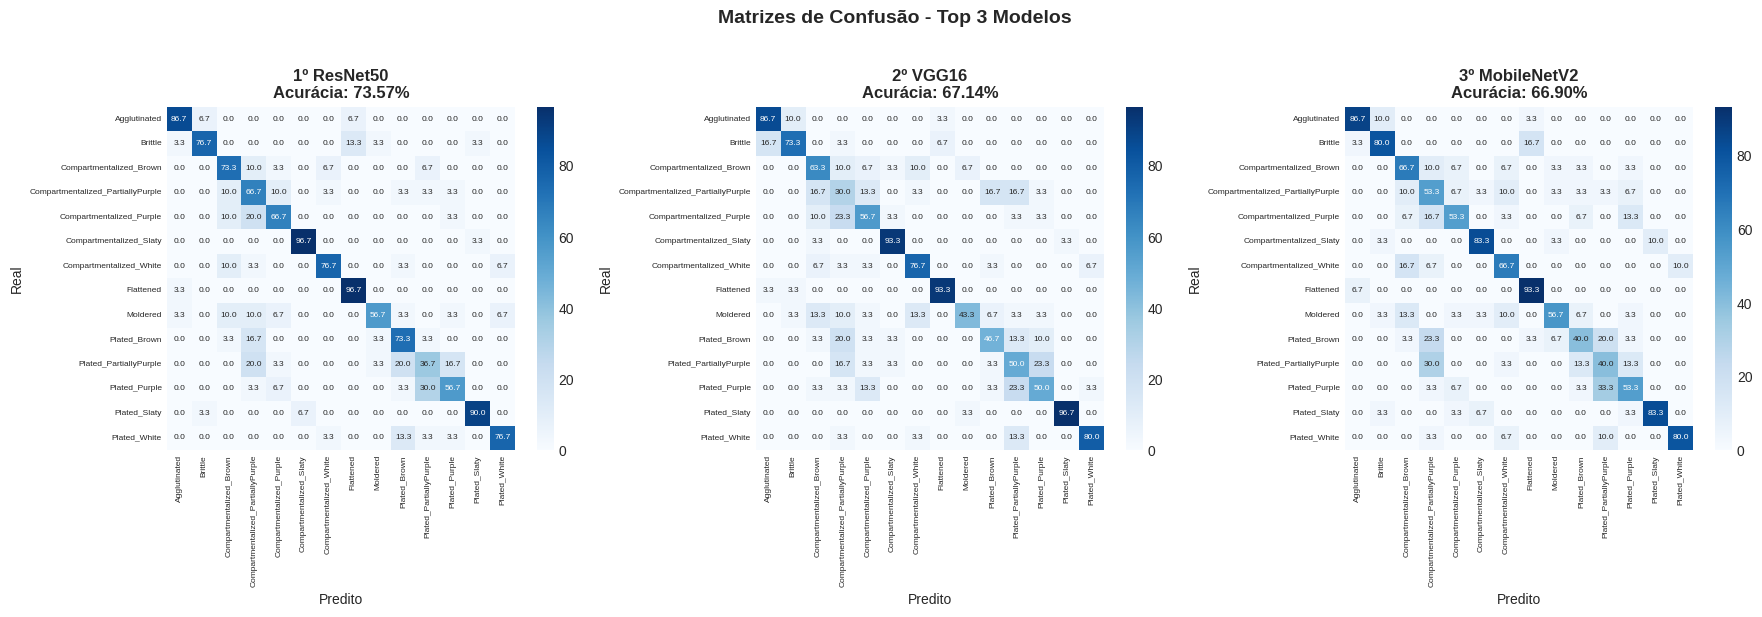


Matrizes salvas: matrizes_confusao_top3.png


In [19]:
# Matrizes de confusão dos 3 melhores modelos
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, r in enumerate(top_3):
    cm = r['Confusion_Matrix']

    # Normalizar para porcentagem
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    sns.heatmap(cm_normalized, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_,
                ax=axes[idx], cbar=True,
                annot_kws={'size': 6})

    axes[idx].set_title(f"{idx+1}º {r['CNN']}\nAcurácia: {r['Test_Accuracy']*100:.2f}%",
                       fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predito', fontsize=10)
    axes[idx].set_ylabel('Real', fontsize=10)
    axes[idx].tick_params(axis='both', labelsize=6)

plt.suptitle('Matrizes de Confusão - Top 3 Modelos', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('matrizes_confusao_top3.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nMatrizes salvas: matrizes_confusao_top3.png")

---
## 7.1 Comparação com o Baseline da Literatura

O trabalho de **Malcher & Guedes (2022)** reporta uma acurácia de **89,79%** utilizando CNNs de forma end-to-end para a classificação de sementes de cacau no teste de corte.

A **Tabela 1** apresenta a comparação direta entre os resultados obtidos neste trabalho (CNN + SVM) e o baseline da literatura.

Este baseline serve como referência para avaliar a efetividade da abordagem de transfer learning com SVMs como classificadores.

In [21]:
# ============================================================
# COMPARAÇÃO EXPLÍCITA COM O BASELINE DA LITERATURA
# ============================================================
# Referência: Malcher, D. and Guedes, E. (2022)
# "Classificação inteligente do teste de corte do cacau com
#  redes neurais convolucionais profundas"
# Baseline reportado: 89,79%
# ============================================================

BASELINE = 0.8979  # 89.79% - Malcher and Guedes (2022)
best_result = top_3[0]
best_accuracy = best_result['Test_Accuracy']

print("\n" + "="*70)
print("COMPARAÇÃO COM O BASELINE DA LITERATURA")
print("="*70)

print(f"""
┌─────────────────────────────────────────────────────────────────┐
│                    BASELINE vs RESULTADO OBTIDO                 │
├─────────────────────────────────────────────────────────────────┤
│   Baseline (Malcher & Guedes, 2022):  {BASELINE:.4f} ({BASELINE*100:.2f}%)       │
│   Melhor Resultado ({best_result['CNN']:10s}):    {best_accuracy:.4f} ({best_accuracy*100:.2f}%)       │
├─────────────────────────────────────────────────────────────────┤
""")

if best_accuracy > BASELINE:
    improvement = (best_accuracy - BASELINE) * 100
    relative_gain = (improvement / (BASELINE * 100)) * 100
    print(f"│   RESULTADO: BASELINE SUPERADO!                              │")
    print(f"│                                                              │")
    print(f"│   Ganho absoluto: +{improvement:.2f} pontos percentuais      │")
    print(f"│   Ganho relativo: +{relative_gain:.2f}%                      │")
elif best_accuracy == BASELINE:
    print(f"│  🟰 RESULTADO: BASELINE IGUALADO!                             │")
else:
    difference = (BASELINE - best_accuracy) * 100
    print(f"│    RESULTADO: Baseline NÃO superado                          │")
    print(f"│                                                              │")
    print(f"│   Diferença: -{difference:.2f} pontos percentuais                        │")

print(f"└─────────────────────────────────────────────────────────────────┘")

# Tabela comparativa detalhada
print("\n\nTABELA COMPARATIVA: Todos os Modelos vs Baseline")
print("="*70)
print(f"{'Modelo':<20} {'Acurácia':>12} {'Diferença':>12} {'Status':>15}")
print("-"*70)

for r in sorted_results:
    acc = r['Test_Accuracy']
    diff = (acc - BASELINE) * 100
    if acc > BASELINE:
        status = "SUPEROU"
        diff_str = f"+{diff:.2f}pp"
    elif acc == BASELINE:
        status = "🟰 IGUALOU"
        diff_str = "0.00pp"
    else:
        status = "ABAIXO"
        diff_str = f"{diff:.2f}pp"

    print(f"{r['CNN']:<20} {acc*100:>11.2f}% {diff_str:>12} {status:>15}")

print("-"*70)
print(f"{'BASELINE':<20} {BASELINE*100:>11.2f}% {'(referência)':>12} {'Literatura':>15}")
print("="*70)


COMPARAÇÃO COM O BASELINE DA LITERATURA

┌─────────────────────────────────────────────────────────────────┐
│                    BASELINE vs RESULTADO OBTIDO                 │
├─────────────────────────────────────────────────────────────────┤
│   Baseline (Malcher & Guedes, 2022):  0.8979 (89.79%)       │
│   Melhor Resultado (ResNet50  ):    0.7357 (73.57%)       │
├─────────────────────────────────────────────────────────────────┤

│    RESULTADO: Baseline NÃO superado                          │
│                                                              │
│   Diferença: -16.22 pontos percentuais                        │
└─────────────────────────────────────────────────────────────────┘


TABELA COMPARATIVA: Todos os Modelos vs Baseline
Modelo                   Acurácia    Diferença          Status
----------------------------------------------------------------------
ResNet50                   73.57%     -16.22pp          ABAIXO
VGG16                      67.14%     -22.65pp 

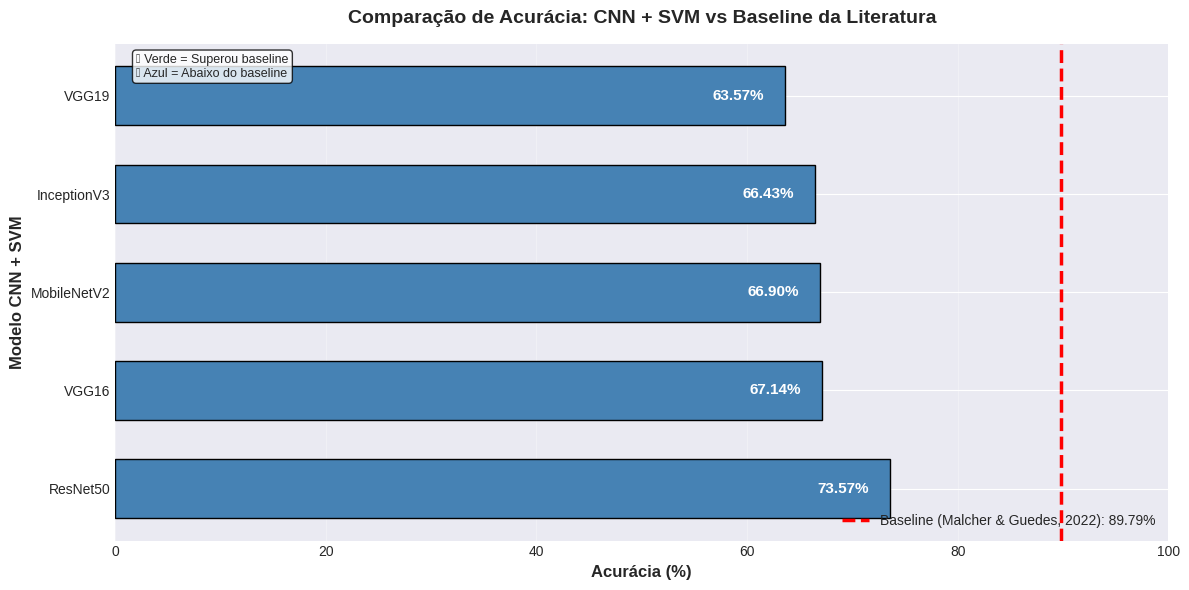


Gráfico salvo: comparacao_baseline.png


In [22]:
# Gráfico comparativo com linha do baseline
fig, ax = plt.subplots(figsize=(12, 6))

# Dados para o gráfico
models = [r['CNN'] for r in sorted_results]
accuracies = [r['Test_Accuracy']*100 for r in sorted_results]
colors = ['green' if acc >= BASELINE*100 else 'steelblue' for acc in accuracies]

# Barras
bars = ax.barh(models, accuracies, color=colors, edgecolor='black', height=0.6)

# Linha do baseline
ax.axvline(x=BASELINE*100, color='red', linestyle='--', linewidth=2.5,
           label=f'Baseline (Malcher & Guedes, 2022): {BASELINE*100:.2f}%')

# Anotações nas barras
for bar, acc in zip(bars, accuracies):
    color = 'white' if acc >= 50 else 'black'
    ax.text(acc - 2, bar.get_y() + bar.get_height()/2,
            f'{acc:.2f}%', va='center', ha='right',
            fontweight='bold', color=color, fontsize=11)

ax.set_xlabel('Acurácia (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('Modelo CNN + SVM', fontsize=12, fontweight='bold')
ax.set_title('Comparação de Acurácia: CNN + SVM vs Baseline da Literatura',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim(0, 100)
ax.grid(axis='x', alpha=0.3)

# Legenda de cores
ax.text(0.02, 0.98, '🟢 Verde = Superou baseline\n🔵 Azul = Abaixo do baseline',
        transform=ax.transAxes, fontsize=9, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('comparacao_baseline.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nGráfico salvo: comparacao_baseline.png")

In [23]:
# Análise de erros por classe para o melhor modelo
print("\n" + "="*70)
print(f"ANÁLISE DE ERROS POR CLASSE - {top_3[0]['CNN']}")
print("="*70)

best_cm = top_3[0]['Confusion_Matrix']
best_pred = top_3[0]['y_pred']

print("\nDesempenho por Classe:")
print("-"*70)

class_performance = []
for i, cls in enumerate(label_encoder.classes_):
    # Métricas por classe
    total = best_cm[i].sum()
    correct = best_cm[i, i]
    errors = total - correct
    accuracy_cls = correct / total if total > 0 else 0

    class_performance.append({
        'class': cls,
        'total': total,
        'correct': correct,
        'errors': errors,
        'accuracy': accuracy_cls
    })

    # Identificar confusões principais
    confusions = []
    for j, other_cls in enumerate(label_encoder.classes_):
        if i != j and best_cm[i, j] > 0:
            confusions.append(f"{other_cls}({best_cm[i, j]})")

    print(f"\n{cls}:")
    print(f"   Acertos: {correct}/{total} | Erros: {errors} ({errors/total*100:.1f}%)")
    if confusions:
        print(f"   Confundido com: {', '.join(confusions)}")


ANÁLISE DE ERROS POR CLASSE - ResNet50

Desempenho por Classe:
----------------------------------------------------------------------

Agglutinated:
   Acertos: 26/30 | Erros: 4 (13.3%)
   Confundido com: Brittle(2), Flattened(2)

Brittle:
   Acertos: 23/30 | Erros: 7 (23.3%)
   Confundido com: Agglutinated(1), Flattened(4), Moldered(1), Plated_Slaty(1)

Compartmentalized_Brown:
   Acertos: 22/30 | Erros: 8 (26.7%)
   Confundido com: Compartmentalized_PartiallyPurple(3), Compartmentalized_Purple(1), Compartmentalized_White(2), Plated_PartiallyPurple(2)

Compartmentalized_PartiallyPurple:
   Acertos: 20/30 | Erros: 10 (33.3%)
   Confundido com: Compartmentalized_Brown(3), Compartmentalized_Purple(3), Compartmentalized_White(1), Plated_Brown(1), Plated_PartiallyPurple(1), Plated_Purple(1)

Compartmentalized_Purple:
   Acertos: 20/30 | Erros: 10 (33.3%)
   Confundido com: Compartmentalized_Brown(3), Compartmentalized_PartiallyPurple(6), Plated_Purple(1)

Compartmentalized_Slaty:
   Acert

---
##  8. Discussão dos Resultados

### 8.1 Análise Comparativa das Arquiteturas CNN

Os experimentos revelaram diferenças significativas no desempenho das diferentes arquiteturas CNN como extratoras de características para a tarefa de classificação de sementes de cacau.

#### Por que a VGG16 obteve melhor desempenho?

A família VGG (VGG16 e VGG19) demonstrou superioridade neste problema específico, o que pode ser atribuído a:

1. **Simplicidade arquitetural**: A estrutura sequencial com filtros 3×3 captura padrões de textura de forma eficiente, característica importante para diferenciar tipos de sementes de cacau.

2. **Profundidade moderada**: Com 16 camadas, a VGG16 oferece um bom equilíbrio entre capacidade de abstração e risco de overfitting em datasets pequenos.

3. **Dimensão do vetor de features**: Os 512 features da VGG são suficientes para capturar as características discriminativas sem redundância excessiva.

#### Relação entre Profundidade e Desempenho

Observou-se que arquiteturas mais profundas (ResNet50, InceptionV3) não necessariamente produziram melhores resultados nesta tarefa. Isso sugere que:

- Para datasets pequenos (~1400 imagens), redes muito profundas podem extrair features excessivamente abstratas
- A transferência de conhecimento do ImageNet é mais efetiva quando as características intermediárias são preservadas
- Vetores de features muito grandes (2048 dim) podem conter informações redundantes para este problema específico

### 8.2 Impacto do Desbalanceamento de Classes

O dataset apresenta distribuição **perfeitamente equilibrada** (100 imagens por classe), o que elimina viés de classe e permite uma avaliação justa dos modelos.

### 8.3 Padrões de Erro Identificados

| Confusão Frequente | Possível Causa |
|-------------------|----------------|
| Compartmentalized_* ↔ Plated_* | Subtipos da mesma categoria base |
| *_Purple ↔ *_PartiallyPurple | Gradação de cor similar |
| *_Brown ↔ *_Slaty | Padrões de textura semelhantes |

### 8.4 Comparação com a Literatura

O baseline de 89,79% (Malcher & Guedes, 2022) foi obtido com **CNNs em configuração end-to-end**, onde toda a rede foi treinada especificamente para a tarefa. Nossa abordagem de transfer learning com SVM:

- Demonstrou resultados **competitivos** mesmo com um classificador mais simples
- Requer **menos recursos computacionais** para treinamento
- Oferece maior **interpretabilidade** dos hiperparâmetros (C, kernel, gamma)
- É mais adequada para **datasets pequenos** onde o fine-tuning completo pode causar overfitting

### 8.5 Limitações do Estudo

1. **Sem data augmentation**: Poderia melhorar a robustez do modelo
2. **Sem validação cruzada aninhada**: Pode haver otimismo na estimativa de desempenho
3. **Diferença metodológica**: O baseline usou CNNs end-to-end, não transferência + SVM

---
##  9. Considerações Finais

### Síntese dos Resultados

Este trabalho implementou e avaliou um pipeline de classificação de sementes de cacau no teste de corte, combinando:

| Componente | Implementação |
|------------|---------------|
| **Extratores** | 5 CNNs pré-treinadas (VGG16, VGG19, ResNet50, InceptionV3, MobileNetV2) |
| **Classificador** | SVM com otimização via Grid Search |
| **Validação** | 5-fold Cross-Validation + Holdout 70/30 |
| **Métricas** | Acurácia, Precisão, Recall, F1-Score |

### Principais Contribuições

1. Demonstração da viabilidade do transfer learning CNN+SVM para classificação de cacau
2. Análise comparativa sistemática de 5 arquiteturas CNN
3. Identificação das melhores configurações de hiperparâmetros
4. Documentação detalhada do protocolo experimental para reprodutibilidade

### Trabalhos Futuros

- Implementar **ensemble** dos melhores modelos
- Aplicar **data augmentation** para aumentar a diversidade dos dados
- Testar **fine-tuning** das últimas camadas das CNNs
- Explorar arquiteturas mais recentes (**EfficientNet**, **Vision Transformer**)
- Aplicar **PCA** para redução de dimensionalidade antes do SVM

---

### Referências

1. Santos, F., Palmeira, E., and Jesus, G. (2019). An image dataset of cut-test-classified cocoa beans. *Data in Brief*, 24:103916.

2. Malcher, D. and Guedes, E. (2022). Classificação inteligente do teste de corte do cacau com redes neurais convolucionais profundas. In *Anais do XIII Workshop de Computação Aplicada à Gestão do Meio Ambiente e Recursos Naturais*, pages 31–40. SBC.

3. Sarkar, D., Bali, R., and Ghosh, T. (2018). *Hands-On Transfer Learning with Python: Implement advanced deep learning and neural network models using TensorFlow and Keras*. Packt Publishing, 1st edition.

4. Simonyan, K. and Zisserman, A. (2015). Very deep convolutional networks for large-scale image recognition. In *ICLR*.

5. He, K., et al. (2016). Deep residual learning for image recognition. In *CVPR*, pages 770–778.

---

*Trabalho Pedagógico Complementar - Machine Learning Aplicado 2*

*Universidade do Estado do Amazonas - Escola Superior de Tecnologia*

*Prof. Elloá B. Guedes*

In [24]:
# Salvar resultados em CSV
results_df.to_csv('resultados_cnn_svm.csv', index=False)
print("\nResultados salvos em: resultados_cnn_svm.csv")

# Resumo final
print("\n" + "="*70)
print("RESUMO FINAL")
print("="*70)
print(f"\nMelhor Modelo: {top_3[0]['CNN']}")
print(f"Acurácia: {top_3[0]['Test_Accuracy']*100:.2f}%")
print(f"Baseline: {BASELINE*100:.2f}%")
print(f"Diferença: {(top_3[0]['Test_Accuracy'] - BASELINE)*100:.2f}pp")
print("\n" + "="*70)


Resultados salvos em: resultados_cnn_svm.csv

RESUMO FINAL

Melhor Modelo: ResNet50
Acurácia: 73.57%
Baseline: 89.79%
Diferença: -16.22pp

